# SBND detector electric field / SCE offset map

Inspect `SBND_DataMap_v3.root`: TH3F maps of true forward/backward displacements and electric field components for the East (`_E`) and West (`_W`) TPCs.

Source: cathode simulation SCE offsets (`jaz8600`).

In [3]:
import numpy as np
import uproot
import matplotlib.pyplot as plt

plt.style.use("presentation.mplstyle")

In [4]:
ROOT_PATH = (
    "/exp/sbnd/app/users/jaz8600/CathodeSimulation/"
    "localProducts_larsoft_v10_06_00_02_e26_prof/sbnd_data/v01_99/"
    "SCEoffsets/SBND_DataMap_v3.root"
)

root_file = uproot.open(ROOT_PATH)
hist_keys = sorted(root_file.keys())

print(f"File: {ROOT_PATH}")
print(f"Histograms ({len(hist_keys)}):")
for key in hist_keys:
    print(f"  {key}")

File: /exp/sbnd/app/users/jaz8600/CathodeSimulation/localProducts_larsoft_v10_06_00_02_e26_prof/sbnd_data/v01_99/SCEoffsets/SBND_DataMap_v3.root
Histograms (20):
  TrueBkwd_Displacement_X_E;1
  TrueBkwd_Displacement_X_W;1
  TrueBkwd_Displacement_Y_E;1
  TrueBkwd_Displacement_Y_W;1
  TrueBkwd_Displacement_Z_E;1
  TrueBkwd_Displacement_Z_W;1
  TrueFwd_Displacement_X_E;1
  TrueFwd_Displacement_X_W;1
  TrueFwd_Displacement_Y_E;1
  TrueFwd_Displacement_Y_W;1
  TrueFwd_Displacement_Z_E;1
  TrueFwd_Displacement_Z_W;1
  True_ElecField_Mag_E;1
  True_ElecField_Mag_W;1
  True_ElecField_X_E;1
  True_ElecField_X_W;1
  True_ElecField_Y_E;1
  True_ElecField_Y_W;1
  True_ElecField_Z_E;1
  True_ElecField_Z_W;1


In [5]:
def hist_axis_info(axis):
    return {
        "nbins": axis.member("fNbins"),
        "xmin": axis.member("fXmin"),
        "xmax": axis.member("fXmax"),
        "title": axis.member("fTitle"),
    }


def summarize_th3(hist):
    vals = hist.values()
    nz = vals[vals != 0]
    return {
        "class": type(hist).__name__,
        "shape": vals.shape,
        "entries": hist.member("fEntries"),
        "x": hist_axis_info(hist.member("fXaxis")),
        "y": hist_axis_info(hist.member("fYaxis")),
        "z": hist_axis_info(hist.member("fZaxis")),
        "nonzero_bins": int(np.count_nonzero(vals)),
        "min": float(np.min(nz)) if nz.size else np.nan,
        "max": float(np.max(nz)) if nz.size else np.nan,
    }


summaries = {key: summarize_th3(root_file[key]) for key in hist_keys}

ref = summaries[hist_keys[0]]
print("Common grid (all histograms share the same binning):")
for axis in ("x", "y", "z"):
    info = ref[axis]
    print(
        f"  {axis.upper():1s}: {info['nbins']:3d} bins, "
        f"[{info['xmin']:8.3f}, {info['xmax']:8.3f}] cm"
        + (f"  ({info['title']})" if info["title"] else "")
    )

print("\nPer-histogram value ranges (nonzero bins only):")
for key in hist_keys:
    s = summaries[key]
    print(f"  {key.split(';')[0]:32s}  min={s['min']: .6g}  max={s['max']: .6g}")

Common grid (all histograms share the same binning):
  X:  49 bins, [-204.167,  204.167] cm
  Y:  49 bins, [-204.167,  204.167] cm
  Z:  61 bins, [  -4.167,  504.167] cm

Per-histogram value ranges (nonzero bins only):
  TrueBkwd_Displacement_X_E         min=-0.775246  max= 0.775246
  TrueBkwd_Displacement_X_W         min=-0.775246  max= 0.775246
  TrueBkwd_Displacement_Y_E         min=-3.39785  max= 3.39788
  TrueBkwd_Displacement_Y_W         min=-3.39785  max= 3.39788
  TrueBkwd_Displacement_Z_E         min=-3.31948  max= 3.31951
  TrueBkwd_Displacement_Z_W         min=-3.31948  max= 3.31951
  TrueFwd_Displacement_X_E          min=-9.45149  max= 6.71264
  TrueFwd_Displacement_X_W          min=-9.45149  max= 6.71264
  TrueFwd_Displacement_Y_E          min=-6.0509  max= 4.09908
  TrueFwd_Displacement_Y_W          min=-6.0509  max= 4.09908
  TrueFwd_Displacement_Z_E          min=-4.73514  max= 3.15263
  TrueFwd_Displacement_Z_W          min=-4.73514  max= 3.15263
  True_ElecField_Mag_E 

In [6]:
def th3_axis_centers(axis):
    nbins = axis.member("fNbins")
    xmin = axis.member("fXmin")
    xmax = axis.member("fXmax")
    edges = np.linspace(xmin, xmax, nbins + 1)
    return 0.5 * (edges[:-1] + edges[1:])


def th3_axis_edges(axis):
    nbins = axis.member("fNbins")
    xmin = axis.member("fXmin")
    xmax = axis.member("fXmax")
    return np.linspace(xmin, xmax, nbins + 1)


def load_th3(key):
    hist = root_file[key]
    return {
        "values": hist.values(),
        "x": th3_axis_centers(hist.member("fXaxis")),
        "y": th3_axis_centers(hist.member("fYaxis")),
        "z": th3_axis_centers(hist.member("fZaxis")),
        "x_edges": th3_axis_edges(hist.member("fXaxis")),
        "y_edges": th3_axis_edges(hist.member("fYaxis")),
        "z_edges": th3_axis_edges(hist.member("fZaxis")),
    }


# Example: electric field magnitude in the East TPC
efield_mag_e = load_th3("True_ElecField_Mag_E;1")
print("Loaded:", "True_ElecField_Mag_E;1")
print("  shape:", efield_mag_e["values"].shape)
print("  z range [cm]:", efield_mag_e["z"][0], "->", efield_mag_e["z"][-1])

Loaded: True_ElecField_Mag_E;1
  shape: (49, 49, 61)
  z range [cm]: -3.278688520680362e-07 -> 500.00000032786886


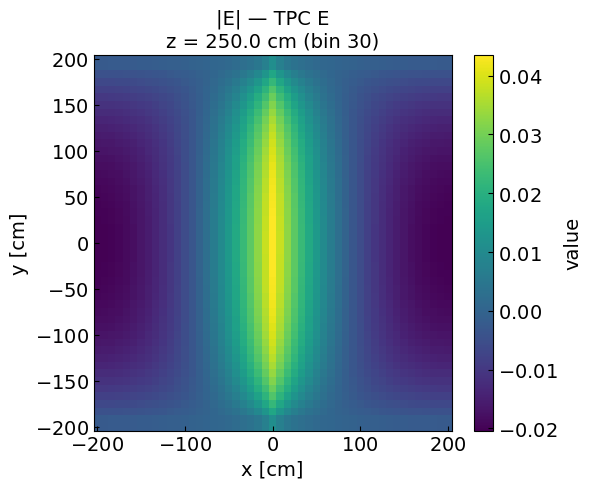

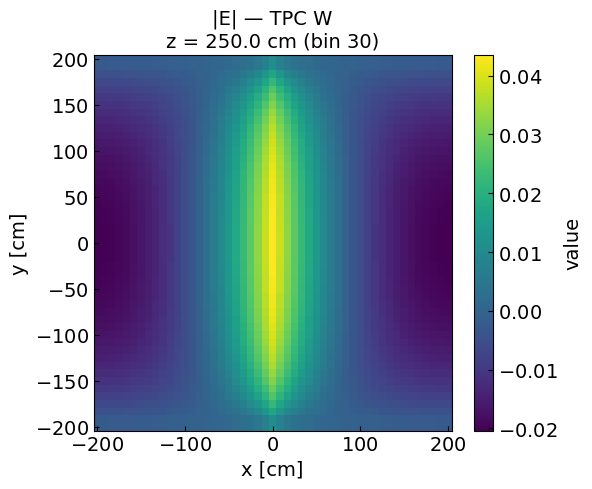

In [7]:
def plot_th3_slices(data, z_cm=None, title="", cmap="viridis"):
    """Plot x-y slices of a TH3 at fixed z (nearest bin if z_cm is given)."""
    vals = data["values"]
    iz = int(np.argmin(np.abs(data["z"] - z_cm))) if z_cm is not None else vals.shape[2] // 2
    slice_xy = vals[:, :, iz].T

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.pcolormesh(
        data["x_edges"],
        data["y_edges"],
        slice_xy,
        shading="auto",
        cmap=cmap,
    )
    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
    ax.set_title(f"{title}\nz = {data['z'][iz]:.1f} cm (bin {iz})")
    fig.colorbar(im, ax=ax, label="value")
    fig.tight_layout()
    return fig, ax


for tpc, z_cm in (("E", 250.0), ("W", 250.0)):
    key = f"True_ElecField_Mag_{tpc};1"
    data = load_th3(key)
    plot_th3_slices(data, z_cm=z_cm, title=f"|E| — TPC {tpc}")
    plt.show()

In [14]:
np.max(data['values'])

np.float32(0.04354938)

In [6]:
# Compare forward vs backward displacement magnitudes at mid-z
z_cm = 250.0

for tpc in ("E", "W"):
    fwd = load_th3(f"TrueFwd_Displacement_X_{tpc};1")["values"]
    fwd_y = load_th3(f"TrueFwd_Displacement_Y_{tpc};1")["values"]
    fwd_z = load_th3(f"TrueFwd_Displacement_Z_{tpc};1")["values"]
    bwd = load_th3(f"TrueBkwd_Displacement_X_{tpc};1")["values"]
    bwd_y = load_th3(f"TrueBkwd_Displacement_Y_{tpc};1")["values"]
    bwd_z = load_th3(f"TrueBkwd_Displacement_Z_{tpc};1")["values"]

    fwd_mag = np.sqrt(fwd**2 + fwd_y**2 + fwd_z**2)
    bwd_mag = np.sqrt(bwd**2 + bwd_y**2 + bwd_z**2)

    iz = int(np.argmin(np.abs(load_th3(f"TrueFwd_Displacement_X_{tpc};1")["z"] - z_cm)))
    print(f"TPC {tpc} @ z={z_cm:.0f} cm:")
    print(f"  |fwd displacement|: min={np.min(fwd_mag[:, :, iz]): .4g}, max={np.max(fwd_mag[:, :, iz]): .4g} cm")
    print(f"  |bwd displacement|: min={np.min(bwd_mag[:, :, iz]): .4g}, max={np.max(bwd_mag[:, :, iz]): .4g} cm")

TPC E @ z=250 cm:
  |fwd displacement|: min= 0, max= 10.55 cm
  |bwd displacement|: min= 8.882e-14, max= 3.398 cm
TPC W @ z=250 cm:
  |fwd displacement|: min= 0, max= 10.55 cm
  |bwd displacement|: min= 8.882e-14, max= 3.398 cm
